# Problema de las velocidades para el IRB140

Análisis del problema de las velocidades para el robot industrial ABB IRB140 utilizando la librería Robotics Toolbox de Peter Corke.

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

In [40]:
# Hacemos todas las importaciones necesarias
# numpy para manejar array y algebra lineal
import numpy as np
import scipy as sc
# la funcionalidad específica de robótica está en el toolbox
import roboticstoolbox as rtb
# spatialmath tiene define los grupos de transformaciones especiales: rotación SO3 y eculideo SE3
import spatialmath as sm
import matplotlib.pyplot as plt  

#%matplotlib inline

## Modelo del robot con PCI analítico

Atención: hacemos d6==0 para estudiar el estado de velocidades de la muñeca

In [66]:
class irb140_clase(rtb.DHRobot):
    def __init__(self, *args, **kwargs):
        super().__init__([
        rtb.RevoluteDH(alpha=-np.pi/2,a=0.07,d = 0.352),
        rtb.RevoluteDH(a=0.36,offset=-np.pi/2),
        rtb.RevoluteDH(alpha=np.pi/2,offset=np.pi),
        rtb.RevoluteDH(d=0.38, alpha=-np.pi/2),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=0)
        ], name="IRB140")

    def get_config(self,q):
        g1 = np.sign(self.links[3].d * np.sin(q[1]+self.links[1].offset +q[2]+self.links[2].offset) + self.links[1].a * np.cos(q[1]+self.links[1].offset) + self.links[0].a)
        g2 = np.sign(np.cos(q[2]+self.links[2].offset))
        g3 = np.sign(np.sin(q[4]+self.links[4].offset))
        return np.array([g1,g2,g3])
    
    def ikine_a(self,POSE,conf=[1,-1,1],q1_actual=0,q4_actual=0):
        # Problema inversor para el robot ABB IRB 140
        # Se determina el vector q

        # Inicializo el vector de variables articulares
        q = np.zeros(6) 

        # Posición
        POSE = sm.SE3(0,0,-self.links[0].d) @ POSE @ sm.SE3(0,0,-self.links[5].d)
        px, py, pz = POSE.t

        # Calculo q1 
        s1 = conf[0]*py
        c1 = conf[0]*px
        if px==0 and py==0:
            q[0] = q1_actual
        else:
            q[0] = np.arctan2(s1,c1)

        # Calculo q3 (codo)
        s3 = ((px*np.cos(q[0]) + py*np.sin(q[0]) - self.links[0].a)**2 + pz**2 - self.links[1].a**2 - self.links[3].d**2)/(2*self.links[1].a*self.links[3].d);
        if (np.abs(s3) > 1):
            print('ERROR: Punto no alcanzable.')
            return np.r[np.nan,np.nan]
        c3 = conf[1]*np.sqrt(1-s3**2)
        q[2] = np.arctan2(s3,c3)

        # Calculo q2
        s2 = (px*np.cos(q[0]) + py*np.sin(q[0]) - self.links[0].a)*(self.links[3].d*np.cos(q[2])) - (self.links[3].d*np.sin(q[2]) + self.links[1].a)*pz
        c2 = (px*np.cos(q[0]) + py*np.sin(q[0]) - self.links[0].a)*(self.links[3].d*np.sin(q[2]) + self.links[1].a) + (self.links[3].d*np.cos(q[2]))*pz
        q[1] = np.arctan2(s2,c2)

        # Calculo el problema de orientacion
        # Calculo R_63
        A60 = self.fkine(q-self.offset)
        R_30 = A60.R
        R_63 = R_30.T @ POSE.R

        # Calculo q5
        c5 = R_63[2,2]
        c5 = np.clip(c5,-1,1)
        q[4] = np.arctan2(conf[2]*np.sqrt(1-c5**2),c5)

        if np.abs(R_63[1,2])<1E-9 and np.abs(R_63[0,2])<1E-9:
            q[3] = q4_actual
            q[5] = np.arctan2(R_63[1,0],R_63[0,0])-q4_actual
        else:
            # Calculo de q4
            s4 = conf[2]*R_63[1,2]
            c4 = conf[2]*R_63[0,2]
            q[3] = np.arctan2(s4,c4)

            # Calculo de q6
            s6 = conf[2]*R_63[2,1]
            c6 = -conf[2]*R_63[2,0]
            q[5] = np.arctan2(s6,c6)

        q = np.angle(np.exp(1j*(q-self.offset)))
        return q


robot = irb140_clase()
print(robot)


DHRobot: IRB140, 6 joints (RRRRRR), dynamics, standard DH parameters
┌────────────┬───────┬──────┬────────┐
│     θⱼ     │  dⱼ   │  aⱼ  │   ⍺ⱼ   │
├────────────┼───────┼──────┼────────┤
│  q1        │ 0.352 │ 0.07 │ -90.0° │
│  q2 - 90°  │     0 │ 0.36 │   0.0° │
│  q3 + 180° │     0 │    0 │  90.0° │
│  q4        │  0.38 │    0 │ -90.0° │
│  q5        │     0 │    0 │  90.0° │
│  q6        │     0 │    0 │   0.0° │
└────────────┴───────┴──────┴────────┘

┌──┬──┐
└──┴──┘



## Análisis del Jacobiano

In [35]:
import sympy as sp

# Variables simbólicas
q = sp.symbols('q1:7')
print(q)

J = robot.jacob0(q)

# NO SIMPLIFICO PORQUE NO TERMINA NUNCA!
#J_simpl = sp.simplify(J)


(q1, q2, q3, q4, q5, q6)


In [24]:
J = sp.Matrix(J)

J11 = J[0:3,0:3]
J12 = J[0:3,3:]
J21 = J[3:,0:3]
J22 = J[3:,3:]

print("Bloque J11")
sp.pprint(J11)

print("Bloque J12")
sp.pprint(J12)

#print("Bloque J22")
#sp.pprint(J22)


#detJ11 = sp.det(J11)
#detJ = sp.simplify(detJ)

#sp.pprint(detJ11)

Bloque J11
⎡(-1.0⋅((((-6.12323399573677e-17⋅sin(q₁)⋅sin(q₂ - 1.5707963267949) + cos(q₁)⋅c ↪
⎢                                                                              ↪
⎢                       (-1.0⋅((((-1.0⋅sin(q₁)⋅sin(q₂ - 1.5707963267949) + 6.1 ↪
⎢                                                                              ↪
⎣                                                                              ↪

↪ os(q₂ - 1.5707963267949))⋅cos(q₃ + 3.14159265358979) + (-6.12323399573677e-1 ↪
↪                                                                              ↪
↪ 2323399573677e-17⋅cos(q₁)⋅cos(q₂ - 1.5707963267949))⋅sin(q₃ + 3.141592653589 ↪
↪                                                                              ↪
↪                                                                              ↪

↪ 7⋅sin(q₁)⋅cos(q₂ - 1.5707963267949) - 1.0⋅sin(q₂ - 1.5707963267949)⋅cos(q₁)) ↪
↪                                                                              ↪
↪ 79) + (sin(q₁

Estos resultados son inmanejables cuando están proyectados en terna 0, aún separando el problema de las velocidades en dos.

Veamos qué conclusiones podemos obtener del cálculo numérico

In [ ]:
# Propongo un set de valores articulares cualquiera
q = np.array([0.2, -0.5, 0.3, 1.0, -0.7, 0.2])

J0 = robot.jacob0(q)

print("Jacobiano en base:")
np.set_printoptions(precision=3, suppress=True)
print(J0)

Jacobiano en base:
[[-0.054  0.384  0.074  0.     0.     0.   ]
 [ 0.264  0.078  0.015  0.     0.     0.   ]
 [-0.    -0.2   -0.372  0.     0.     0.   ]
 [-0.    -0.199 -0.199  0.961 -0.271  0.775]
 [-0.     0.98   0.98   0.195  0.496 -0.396]
 [ 1.    -0.    -0.     0.199  0.825  0.493]]


Queda más claro el desacoplamiento de la velocidad de traslación de la muñeca y la velocidad de rotación de la terna 6, pero aún hay muchos valores no nulos que ocultan ciertos patrones.

Ver qué pasaría si d6!=0 

In [30]:
A = robot.fkine_all(q)
R03 = A[3].R.T
R04 = A[4].R.T

Jv = J0[0:3, :]
Jw = J0[3:6, :]

Jv_3 = R03 @ Jv
Jw_3 = R04 @ Jw

J3 = np.vstack((Jv_3, Jw_3))

print("Jacobiano proyectado en terna 3:")
print(np.round(J3, 3))

Jacobiano proyectado en terna 3:
[[ 0.     0.274  0.38   0.     0.     0.   ]
 [ 0.27  -0.     0.     0.     0.     0.   ]
 [ 0.     0.344  0.     0.     0.     0.   ]
 [-0.53   0.841  0.841 -0.    -0.    -0.644]
 [-0.199 -0.    -0.    -1.     0.    -0.765]
 [ 0.825  0.54   0.54  -0.     1.     0.   ]]


No cambié el robot. Solo cambié desde dónde lo miro

In [37]:
print("Bloque brazo (1–3):")
print(J3[0:3, 0:3])

print("\nBloque muñeca (4–6):")
print(J3[3:, 3:])

Bloque brazo (1–3):
[[ 0.     0.274  0.38 ]
 [ 0.27  -0.     0.   ]
 [ 0.     0.344  0.   ]]

Bloque muñeca (4–6):
[[-0.    -0.    -0.644]
 [-1.     0.    -0.765]
 [-0.     1.     0.   ]]


Observando los valores nulos de cada bloque se pueden interpretar las capacidades de movimiento del robot

# Singularidades

En esta sección se analizan tres singularidades principales del ABB IRB140:

- **Singularidad de la muñeca** (joints 4-5-6)
- **Singularidad del brazo** (configuración del hombro/codo con muñeca alineada)
- **Singularidad del codo** (ángulo de codo crítico)

El objetivo es usar matrices Jacobianas y descomposición SVD para identificar modos de movimiento prohibidos y espacios nulos en velocidad.


## Singularidad de muñeca

Se evalúa el Jacobiano en q = [0, 0, 0, 0, 0, 0] donde el eje 4 y el 6 están alineados. En esta condición se espera pérdida de grado de libertad en la parte rotacional y un espacio nulo asociado a la dirección bloqueada.

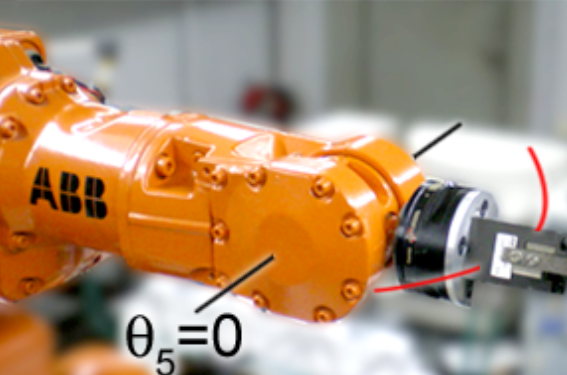


In [63]:
# Singularidad de muñeca en q = [0,0,0,0,0,0]
np.set_printoptions(precision=3,suppress=True)
qsing = np.r_[0,0,0,0,0,0]
J = robot.jacob0(qsing)

# Proyecto el bloque de rotación en la terna 4
A = robot.fkine_all(qsing)
J22_4 = A[4].R.T @ J[3:,3:]
print("Bloque de rotación del Jacobiano expresado en terna 4:\n", J22_4)

# Reportar resultados clave 
print("Determinante Jacobiano:", np.linalg.det(J))
print("Espacio nulo de J:")
print(sc.linalg.null_space(J22_4).ravel())
print("Espacio nulo de J^T (en terna 4):")
print(sc.linalg.null_space(J22_4.T).ravel())

Bloque de rotación del Jacobiano expresado en terna 4:
 [[ 0.  0.  0.]
 [-1. -0. -1.]
 [ 0.  1.  0.]]
Determinante Jacobiano: 8.59527065895444e-67
Espacio nulo de J:
[ 0.707  0.    -0.707]
Espacio nulo de J^T (en terna 4):
[-1.  0.  0.]


## Singularidad de brazo

En esta parte se busca $\mathbf{q}$ que lleva la muñeca sobre el eje 1. Se analiza cómo se comporta el Jacobiano (determinante cero) y el espacio nulo en velocidades cartesianas y articulares.

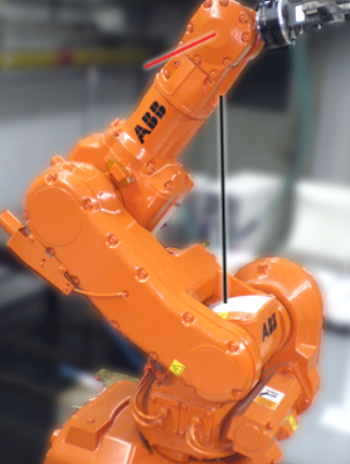

Evaluamos el jacobiano en la singularidad del brazo. Para esto vamos a averiguar el q que lleva la muñeca a un punto del eje 1.

Atención: dejé la herramienta con $\mathbf{z}_\text{tool0}$ en dirección de $\mathbf{z}_0$


In [62]:
POSE = sm.SE3.Trans(0,0,0.500) @ sm.SE3.Eul(0,0,0)
print("POSE que queda en la singularidad del brazo:\n ", POSE)
# Si uso el analítico anda de una 
qsing,_ = robot.ikine_a(POSE,conf=[1,1,1])
#qsing = robot.ikine_LM(POSE).q

print("q singular:",qsing)
J = robot.jacob0(qsing)

A = robot.fkine_all(qsing)
J11_3 = A[3].R.T @ J[:3,:3]
print("Bloque de traslación del Jacobiano expresado en terna 3:\n", J11_3)

print("Determinante: ",np.linalg.det(J))
print("Espacio Nulo de J:\n",sc.linalg.null_space(J11_3).ravel())
print("Espacio Nulo de J transpuesto:\n",sc.linalg.null_space(J11_3.transpose()).ravel())

U,S,Vt = sc.linalg.svd(J11_3)
print("Valores Singulares: ",S)
print("Ultima fila de Vt: ",Vt[-1,:])
print("Ultima columna de U: ",U[:,-1])


POSE que queda en la singularidad del brazo:
     1         0         0         0         
   0         1         0         0         
   0         0         1         0.5       
   0         0         0         1         

q singular: [0.    1.027 2.014 0.    1.672 0.   ]
Bloque de traslación del Jacobiano expresado en terna 3:
 [[ 0.     0.055  0.38 ]
 [-0.     0.    -0.   ]
 [ 0.    -0.154  0.   ]]
Determinante:  -3.2382183940112122e-18
Espacio Nulo de J:
 [-1. -0.  0.]
Espacio Nulo de J transpuesto:
 [0. 1. 0.]
Valores Singulares:  [0.385 0.152 0.   ]
Ultima fila de Vt:  [-1. -0.  0.]
Ultima columna de U:  [0. 1. 0.]


## Singularidad de codo

Corresponde a la configuración donde $q_3 = -\pi/2$ (o equivalente) y el eslabón del brazo está alineado de modo que el grado de libertad de rotación del codo se pierde. Aquí se analiza el Jacobiano y los modos singulares con SVD.

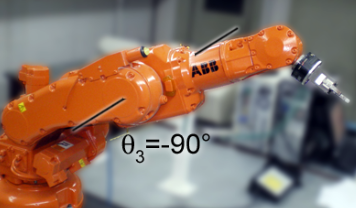

In [ ]:
# Evaluamos la singularidad del codo en la pose de la figura
qsing = np.r_[0,np.pi/4,-np.pi/2,0,np.pi/4,0]

J = robot.jacob0(qsing)

#A = robot.fkine_all(qsing)
#J11_3 = A[3].R.T @ J[:3,:3]
J11_3 = J[:3,:3]
print("Bloque de traslación del Jacobiano expresado en terna 3:\n", J11_3)

print("Determinante: ",np.linalg.det(J))
U,S,Vt = sc.linalg.svd(J11_3)
print("Valores Singulares: ",S)
print("Espacio Nulo de J:\n",Vt[-1,:])
print("Espacio Nulo de J transpuesto:\n",U[:,-1])


   0         0         1         0.5933    
   0         1         0         0         
  -1         0         0         0.8753    
   0         0         0         1         

Bloque de traslación del Jacobiano expresado en terna 3:
 [[ 0.     0.523  0.269]
 [ 0.593  0.     0.   ]
 [-0.    -0.523 -0.269]]
Determinante:  -1.1855696785861646e-17
Valores Singulares:  [0.832 0.593 0.   ]
Espacio Nulo de J:
 [-0.     0.457 -0.89 ]
Espacio Nulo de J transpuesto:
 [0.707 0.    0.707]


In [65]:
# No dice demasiado, Lo mejor sería proyectar la velocidad en terna 3
# En este caso la dirección prohibida debería ser z_3
POSE = robot.fkine_all(qsing)
R_03 = POSE[3].R
null_Jt = R_03.T @ U[0:3,-1].transpose()
print(null_Jt)

[ 0. -0.  1.]


## Análisis de movimientos cartesianos cercanos a la singularidad 

Se grafica el perfil de posiciones articulares y espaciales (solo posición) para un movimiento en línea recta en la dirección Y_0

In [67]:
# Trazamos la trayectoria recta en forma iterativa usando el Jacobiano
#
# Primero armamos una función que simule el movimiento, porque al estudiar distintos
# casos es mejor no repetir código

def simular_movimiento(POSE_ini,POSE_fin,tiempo_mov=2,n_steps=200):
  # Inicializo las variables que definen el movimiento deseado
  dx = (POSE_fin.t - POSE_ini.t)/n_steps
  dx = dx.reshape(3,1)
  dw = np.zeros((3,1))
  dt = tiempo_mov/n_steps

  q_acum = np.empty((n_steps, 6))
  qp_acum = np.empty((n_steps, 6))
  X_acum = np.empty((n_steps, 3))

  q = robot.ikine_a(POSE_ini)
  for idx_step in range(n_steps):
      J = robot.jacob0(q)
      J_pinv = sc.linalg.pinv(J)
      V = np.vstack((dx, dw)) / dt
      qp = np.reshape(J_pinv @ V, (6,))

      q += qp * dt
      q_acum[idx_step, :] = q
      qp_acum[idx_step, :] = qp
      X_acum[idx_step, :] = np.reshape(robot.fkine(q).t, (1, 3))

  # Gráficos
  #robot.plot(q_acum, backend='pyplot')

  plt.figure(figsize=(5,5))
  t = np.linspace(0, 1, n_steps)
  plt.subplot(2, 1, 1)
  plt.plot(t, q_acum * 180 / np.pi)
  plt.title('Posiciones articulares')
  plt.xlabel('Tiempo [s]')
  plt.ylabel('$q(t)$ [°]')
  plt.legend(['$q_1$', '$q_2$', '$q_3$', '$q_4$', '$q_5$', '$q_6$'])

  plt.subplot(2,1,2)
  plt.plot(t, qp_acum*180/np.pi)
  plt.title('Velocidades articulares')
  plt.xlabel('Tiempo [s]')
  plt.ylabel('$\dot{q}(t)$ [°/s]')
  plt.legend(['$\dot{q}_1$','$\dot{q}_2$','$\dot{q}_3$','$\dot{q}_4$','$\dot{q}_5$','$\dot{q}_6$'])
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(5,5))
  plt.plot(t,X_acum[:,:]*1000)
  plt.title('Posiciones cartesianas')
  plt.xlabel('Tiempo [s]')
  plt.ylabel('POS [mm]')
  plt.legend(['$x$', '$y$','$z$'])
  plt.tight_layout()
  plt.show()

## Pasando cerca de la singularidad del brazo

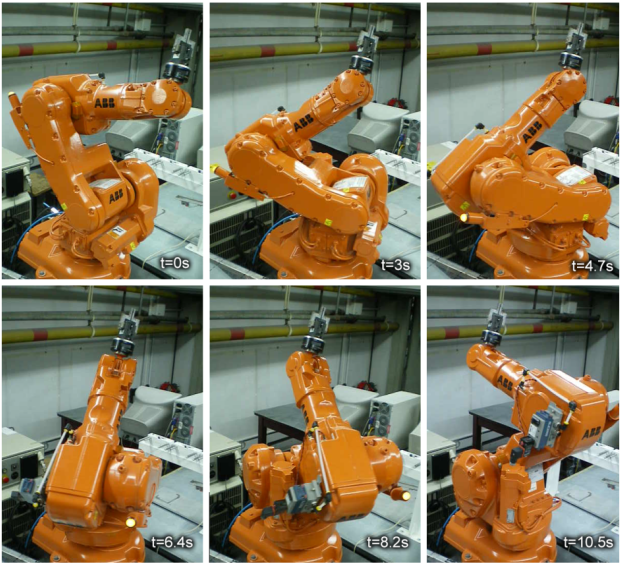

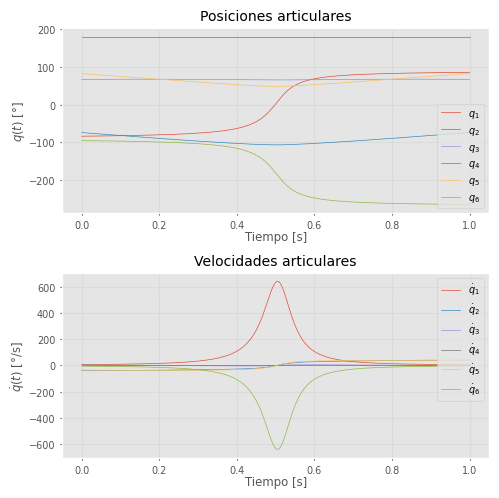

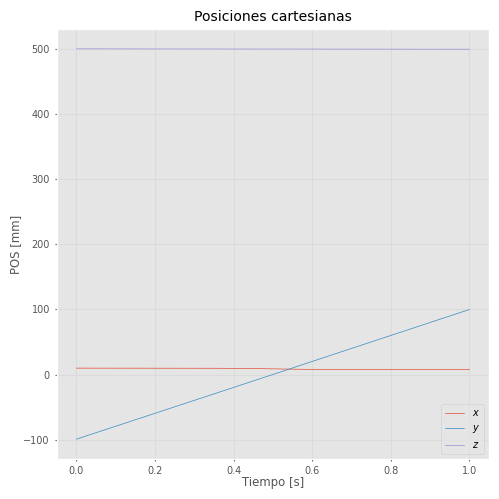

In [68]:
# Esto pasa por la singularidad del brazo
POSE_ini = sm.SE3.Trans(0.01,-0.100,0.5)
POSE_fin = sm.SE3.Trans(0.01,0.100,0.5)
simular_movimiento(POSE_ini,POSE_fin)


## Pasando cerca de la singularidad de la muñeca

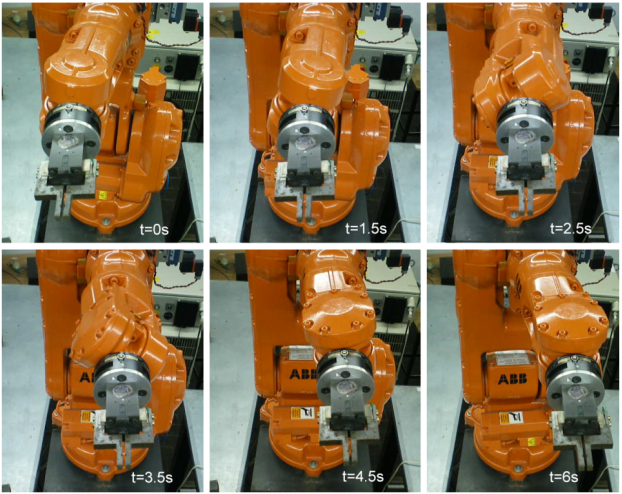

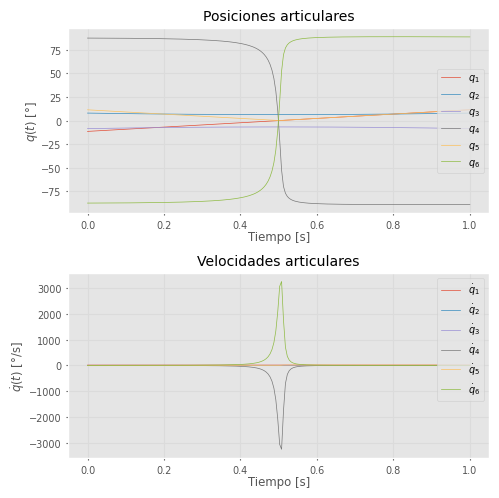

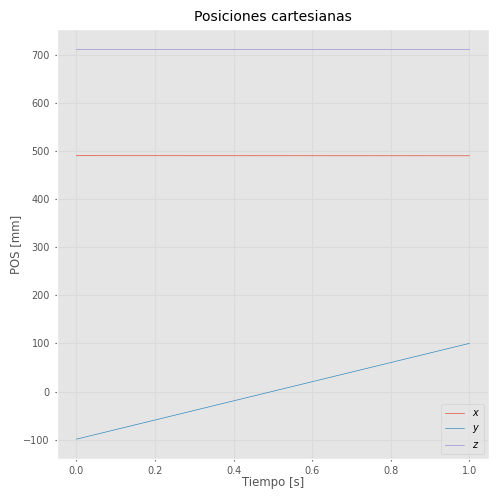

In [69]:
# Esto pasa por la singularidad de la muñeca
POSE_zero = robot.fkine(np.zeros(6))
POSE_ini = POSE_zero * sm.SE3(0,-0.100,0.04)
POSE_fin = POSE_zero * sm.SE3(0,0.100,0.04)

simular_movimiento(POSE_ini,POSE_fin)

## Yendo hacia la singularidad del codo

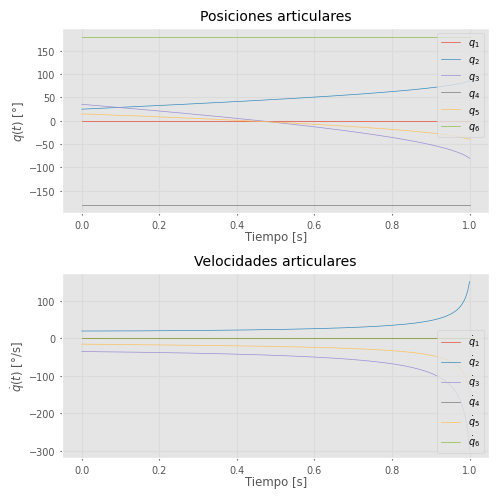

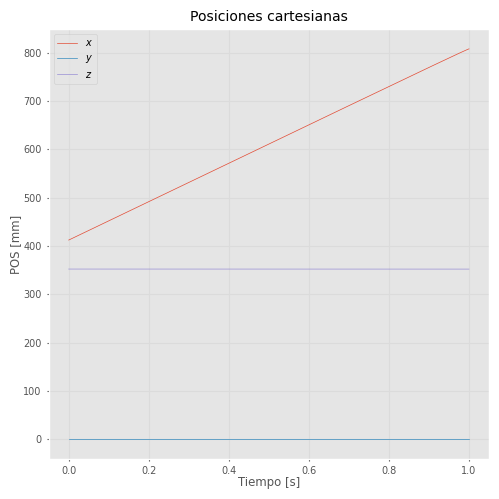

In [70]:
q_sing_codo = np.r_[0,np.pi/2,-np.pi/2,0,np.pi/4,0]
POSE_fin = robot.fkine(q_sing_codo)
POSE_ini = sm.SE3(-0.4,0,0) * POSE_fin  

simular_movimiento(POSE_ini,POSE_fin)